## Reranking Methods in RAG Systems

### Overview
Reranking is a crucial step in Retrieval-Augmented Generation (RAG) systems that aims to improve the relevance and quality of retrieved documents. It involves reassessing and reordering initially retrieved documents to ensure that the most pertinent information is prioritized for subsequent processing or presentation.

### Motivation
The primary motivation for reranking in RAG systems is to overcome limitations of initial retrieval methods, which often rely on simpler similarity metrics. Reranking allows for more sophisticated relevance assessment, taking into account nuanced relationships between queries and documents that might be missed by traditional retrieval techniques. This process aims to enhance the overall performance of RAG systems by ensuring that the most relevant information is used in the generation phase.

### Key Components
Reranking systems typically include the following components:

1. Initial Retriever: Often a vector store using embedding-based similarity search.
2. Reranking Model: This can be either:
    * A Large Language Model (LLM) for scoring relevance
    * A Cross-Encoder model specifically trained for relevance assessment
3. Scoring Mechanism: A method to assign relevance scores to documents
4. Sorting and Selection Logic: To reorder documents based on new scores

### Method Details
The reranking process generally follows these steps:

1. Initial Retrieval: Fetch an initial set of potentially relevant documents.
2. Pair Creation: Form query-document pairs for each retrieved document.
3. Scoring:
    * LLM Method: Use prompts to ask the LLM to rate document relevance.
    * Cross-Encoder Method: Feed query-document pairs directly into the model.
4. Score Interpretation: Parse and normalize the relevance scores.
5. Reordering: Sort documents based on their new relevance scores.
6. Selection: Choose the top K documents from the reordered list.

### Benefits of this Approach
Reranking offers several advantages:

1. Improved Relevance: By using more sophisticated models, reranking can capture subtle relevance factors.
2. Flexibility: Different reranking methods can be applied based on specific needs and resources.
3. Enhanced Context Quality: Providing more relevant documents to the RAG system improves the quality of generated responses.
4. Reduced Noise: Reranking helps filter out less relevant information, focusing on the most pertinent content.

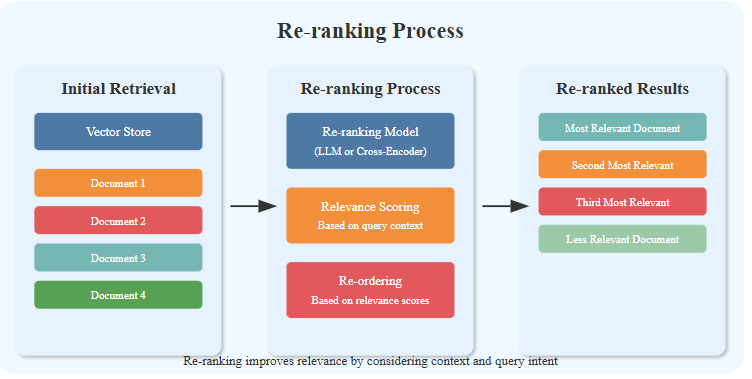

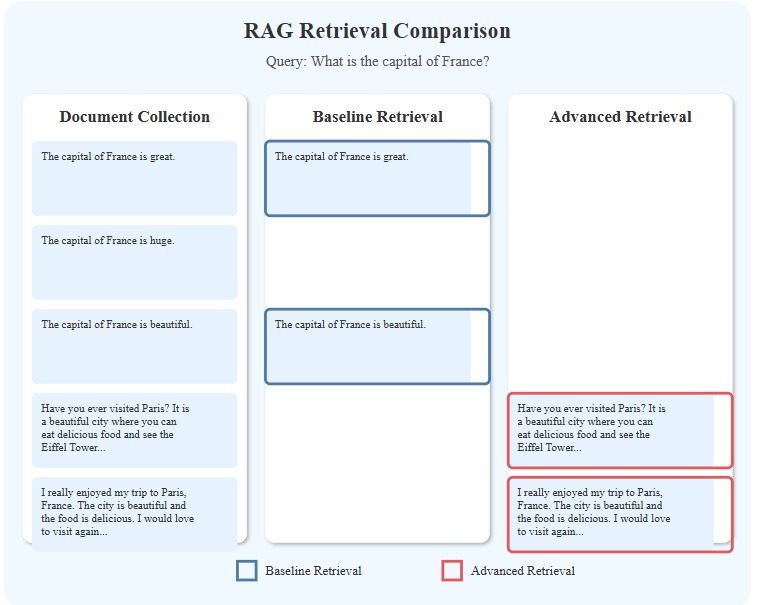

## Imports

In [2]:
import os
print(os.listdir('.')) 

['reranking.ipynb']


In [36]:
import os
import sys
from dotenv import load_dotenv
from langchain_core.documents import Document
from typing import List, Optional, Dict, Any, Tuple
from langchain_groq import ChatGroq
from langchain_core.retrievers import BaseRetriever
from sentence_transformers import CrossEncoder
load_dotenv()
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

In [4]:
sys.path.append('../')  # Go up one level
from helper_functions import *

#### Create a vectore store

In [10]:
path=r"C:\Users\birok\Python\MLOPs\RAG-Techniques\data\Understanding_Climate_Change.pdf"

In [12]:
vectorstore= encode_pdf(path)

### Method 1: LLM based function to rerank the retrieved documents
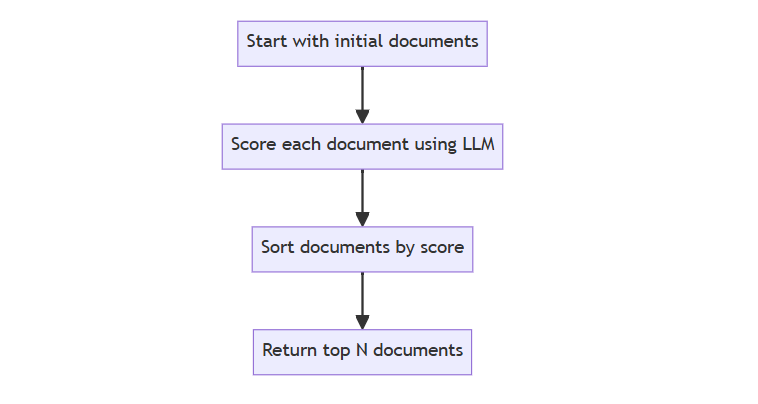

### Create a custom reranking function

In [22]:
class RatingScore(BaseModel):
    relevance_score: float = Field(..., description="The relevance score of a document to a query.")

def rerank_documents(query: str, docs: List[Document], top_n: int = 3) -> List[tuple[Document, float]]:
    prompt_template = PromptTemplate(
        input_variables=["query", "doc"],
        template="""On a scale of 1-10, rate the relevance of the following document to the query. Consider the specific context and intent of the query, not just keyword matches.
        Query: {query}
        Document: {doc}
        Relevance Score:"""
    )
    
    llm = ChatGroq(temperature=0, model_name="openai/gpt-oss-120b", max_tokens=4000)
    llm_chain = prompt_template | llm.with_structured_output(RatingScore)
    
    scored_docs = []
    for doc in docs:
        input_data = {"query": query, "doc": doc.page_content}
        score = llm_chain.invoke(input_data).relevance_score
        try:
            score = float(score)
        except ValueError:
            score = 0  # Default score if parsing fails
        scored_docs.append((doc, score))
    
    reranked_docs = sorted(scored_docs, key=lambda x: x[1], reverse=True)
    return reranked_docs[:top_n]

### Example usage of the reranking function with a sample query relevant to the document

In [23]:
query= "What are the impacts of climate change on biodiversity?"
initial_docs= vectorstore.similarity_search(query=query, k=15)
reranked_docs= rerank_documents(query, initial_docs)

In [25]:
# Print first 3 initial documents
print("Top initial documents:")
for i, doc in enumerate(initial_docs[:3]):
    print(f"\nDocument {i+1}")
    print(doc.page_content[:200] + "...")

# Print reranked results with scores
print(f"\nQuery: {query}\n")
print("Top reranked documents:")
for i, (doc, score) in enumerate(reranked_docs):  # Unpack the tuple
    print(f"\nDocument {i+1} | Relevance Score: {score:.1f}/10")
    print(doc.page_content[:200] + "...")

Top initial documents:

Document 1
Climate change is altering terrestrial ecosystems by shifting habitat ranges, changing species 
distributions, and impacting ecosystem functions. Forests, grasslands, and deserts are 
experiencing shi...

Document 2
Heatwaves can lead to heat-related illnesses and exacerbate existing health conditions. 
Changing Seasons 
Climate change is altering the timing and length of seasons, affecting ecosystems and human 
...

Document 3
cultural perceptions. 
Youth Engagement 
Youth are vital stakeholders in climate action. Empowering young people through education, 
activism, and leadership opportunities can drive transformative cha...

Query: What are the impacts of climate change on biodiversity?

Top reranked documents:

Document 1 | Relevance Score: 9.0/10
Climate change is altering terrestrial ecosystems by shifting habitat ranges, changing species 
distributions, and impacting ecosystem functions. Forests, grasslands, and deserts are 
experiencing shi..

### Method 2: Cross Encoder models
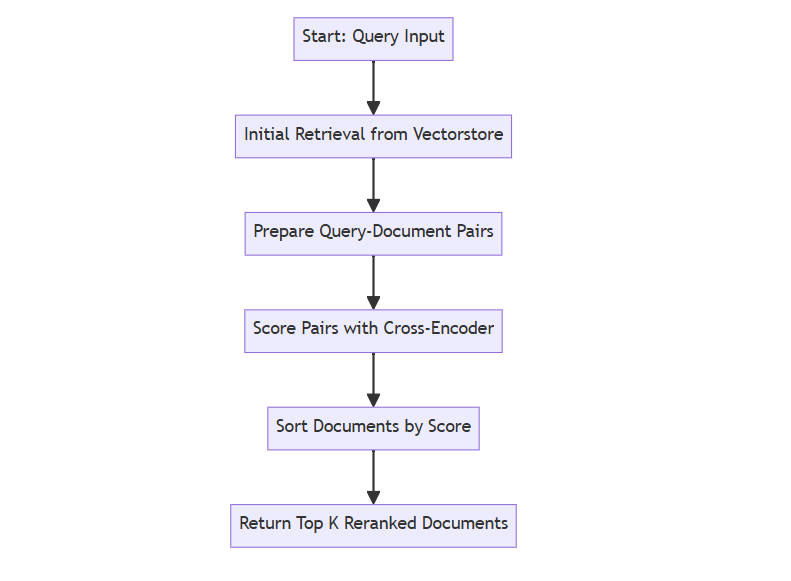

#### Define the cross encoder class

In [34]:
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

class CrossEncoderRetriever(BaseRetriever, BaseModel):
    vectorstore: Any = Field(description="Vector store for initial retrieval")
    cross_encoder: Any = Field(description="Cross-encoder model for reranking")
    k: int = Field(default=5, description="Number of documents to retrieve initially")
    rerank_top_k: int = Field(default=3, description="Number of documents to return after reranking")

    class Config:
        arbitrary_types_allowed = True

    def _get_relevant_documents(self, query: str) -> List[Document]:
        
        # Initial retrieval
        initial_docs = self.vectorstore.similarity_search(query, k=self.k)
        
        # Prepare pairs for cross-encoder
        pairs = [[query, doc.page_content] for doc in initial_docs]
        
        # Get cross-encoder scores
        scores = self.cross_encoder.predict(pairs)
        
        # Sort documents by score
        scored_docs = sorted(zip(initial_docs, scores), key=lambda x: x[1], reverse=True)
        
        # Return top reranked documents
        return [doc for doc, _ in scored_docs[:self.rerank_top_k]]

    async def aget_relevant_documents(self, query: str) -> List[Document]:
        raise NotImplementedError("Async retrieval not implemented")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 559.78it/s, Materializing param=classifier.weight]                                    
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\birok\AppData\Local\Temp\ipykernel_13440\399113732.py:3: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class CrossEncoderRetriever(BaseRetriever, BaseModel):


#### Create an instance and showcase over an example

In [37]:
# Create the cross-encoder retriever
cross_encoder_retriever = CrossEncoderRetriever(
    vectorstore=vectorstore,
    cross_encoder=cross_encoder,
    k=10,
    rerank_top_k=5
)

# Set up the LLM
llm = ChatGroq(temperature=0, model_name="openai/gpt-oss-120b", max_tokens=4000)

# Prompt template
prompt = ChatPromptTemplate.from_template("""
Answer the question based only on the following context:

{context}

Question: {question}
""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Build the chain using LCEL
rag_chain_with_sources = RunnableParallel(
    {
        "source_documents": cross_encoder_retriever,
        "result": (
            RunnableParallel({
                "context": cross_encoder_retriever | format_docs,
                "question": RunnablePassthrough()
            })
            | prompt
            | llm
            | StrOutputParser()
        )
    }
)

# Example query
query = "What are the impacts of climate change on biodiversity?"
result = rag_chain_with_sources.invoke(query)

print(f"\nQuestion: {query}")
print(f"Answer: {result['result']}")
print("\nRelevant source documents:")
for i, doc in enumerate(result["source_documents"]):
    print(f"\nDocument {i+1}:")
    print(doc.page_content[:200] + "...")


Question: What are the impacts of climate change on biodiversity?
Answer: Climate change is reshaping biodiversity in several ways:

* **Shifts in habitat ranges** – As temperatures rise, the geographic limits of many habitats move, forcing plants and animals to relocate to new areas.  
* **Changes in species distributions** – Species that once thrived in particular ecosystems (forests, grasslands, deserts, coral reefs, deep‑sea habitats) are now found elsewhere, while some may disappear from parts of their historic range.  
* **Altered ecosystem composition** – The mix of plant and animal species in terrestrial systems (forests, grasslands, deserts) and marine systems (coral reefs, open ocean, deep sea) is changing, leading to new community structures.  
* **Loss of biodiversity** – The combined effect of range shifts, mismatched species interactions, and habitat alteration can reduce overall species richness and erode genetic diversity.  
* **Disruption of ecological balance** – Cha

* Used `RunnableParallel` to simultaneously fetch source docs and generate the answer
* Used `RunnablePassthrough` to pass the query through unchanged to the prompt